In [1]:
import pandas as pd 
import glob

In [2]:
sf_meeting_calendars = glob.glob(
    '../data/city-council-meeting-minutes/all-links-to-pdfs-in-bay-area/*/san-francisco.csv'
)

In [3]:
all_cals = []
for cal in sf_meeting_calendars:
    cal_df = (
        pd.read_csv(cal, index_col=0)
             .loc[lambda df: df['doc_type'] == 'Meeting Details']
             .loc[lambda df: df['committee'] == 'Board of Supervisors']
    )
    all_cals.append(cal_df)

In [4]:
# pd.concat(all_cals)

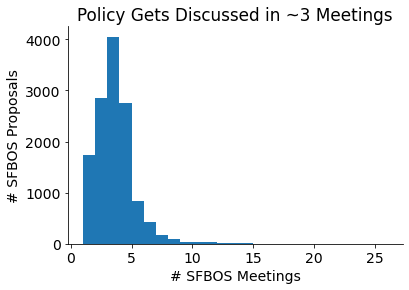

In [6]:
import matplotlib.pyplot as plt 
full_meeting_row_df = pd.read_csv('cache/2023-04-13__full_meeting_row_df.csv')

plt.rc('font', size=14)
ax = full_meeting_row_df['File #'].value_counts().hist(bins=25, figsize=(6,4))
ax.grid(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('# SFBOS Proposals')
ax.set_xlabel('# SFBOS Meetings')
ax.set_title('Policy Gets Discussed in ~3 Meetings')
plt.savefig('../latex/emnlp2023/figures/policy-histogram.png', bbox_inches='tight')

# Look at linking analysis

In [78]:
final_matching_df = (
    pd.read_csv('cache/final-matching-articles-and-meetings.csv', index_col=0)
#         .drop_duplicates(['meeting date', 'File #'])
)

In [9]:
full_meeting_row_df = pd.read_csv('cache/2023-04-13__full_meeting_row_df.csv')
full_meeting_row_df = full_meeting_row_df.assign(text=lambda df: df['Name'] + '. ' + df['Title']).drop(columns=['Name', 'Title'])
full_meeting_row_df['date'] = pd.to_datetime(full_meeting_row_df['date'])
full_meeting_row_df = (
    full_meeting_row_df
#         .drop_duplicates(['date', 'File #'])
        .drop_duplicates(['File #'])    
        .loc[lambda df: df['committee'] == 'Board of Supervisors']
)

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_39447/3104298375.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals])


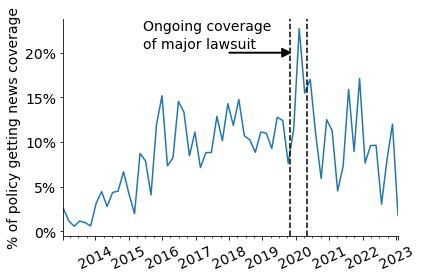

In [62]:
import matplotlib.dates as md

date_bins = full_meeting_row_df['date'].pipe(lambda s: pd.date_range(s.min(), s.max(), freq='60D'))

proportional_coverage = pd.concat([
    pd.cut(full_meeting_row_df['date'], bins=date_bins).value_counts().to_frame('total counts'),
    pd.cut(pd.to_datetime(final_matching_df['meeting date']), bins=date_bins).value_counts().sort_index().to_frame('covered counts')
], axis=1).pipe(lambda df: df['covered counts'] / df['total counts'])

ax = proportional_coverage.rename(index=lambda x: x.left).plot()
plt.xticks(rotation=25, horizontalalignment='center');
vals = ax.get_yticks()
ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylabel('% of policy getting news coverage')


from datetime import datetime
ymin, ymax = plt.ylim()
x0 = md.date2num(datetime(2018, 1, 1))
x1 = md.date2num(datetime(2019, 8, 1))
plt.arrow(
    x0,
    .2,  
    x1 - x0, 
    0,
    edgecolor='black',
    facecolor='black',
    head_length=100,
    head_width=.01
)
plt.vlines(datetime(2019, 11, 1), ymin, ymax, linestyles='dashed', color='black')
plt.vlines(datetime(2020, 5, 1), ymin, ymax, linestyles='dashed', color='black')
plt.text(datetime(2015, 6, 1), .225, s='Ongoing coverage')
plt.text(datetime(2015, 6, 1), .205, s='of major lawsuit')
plt.ylim((ymin, ymax))

plt.savefig('../latex/emnlp2023/figures/coverage-over-time.png', bbox_inches='tight')

In [ ]:
(final_matching_df
     .loc[lambda df: df['meeting date'] < '2020-03-01']
     .loc[lambda df: df['meeting date'] > '2019-12-01'] 
)['meeting text'].drop_duplicates().head(10).values

In [70]:
import urllib
from unidecode import unidecode
def parse_path(url):
    path = url.split(')')[-1]
    path = path.split('sfchronicle.com')[-1]
    path = urllib.parse.unquote(path, encoding='utf-8', errors='replace')
    path = unidecode(path).replace(' ', '')
    return path.lower()

In [81]:
final_matching_df['paths'] = final_matching_df['article_url'].apply(parse_path)

In [95]:
1015 / 12930

0.07849961330239752

In [94]:
(final_matching_df
 .drop_duplicates(['File #']).shape 

)

(1015, 9)

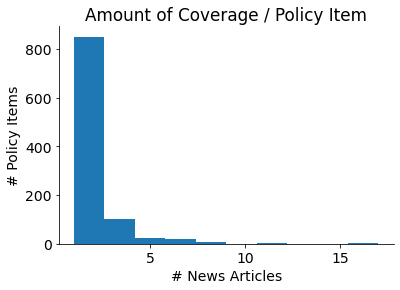

In [104]:
ax = (final_matching_df
 .drop_duplicates(['File #', 'paths'])
 ['File #']
 .value_counts().hist()
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.set_ylabel('# Policy Items')
ax.set_xlabel('# News Articles')
ax.set_title('Amount of Coverage / Policy Item')
plt.savefig('../latex/emnlp2023/figures/coverage-per-policy-item.png', bbox_inches='tight')

In [106]:
top_covered_policies = (
    final_matching_df
     .drop_duplicates(['File #', 'paths'])
     ['File #']
     .value_counts()
)

In [109]:
top_covered_policies.mean()

1.800985221674877

In [114]:
top_covered_policies

180694    17
180214    16
200363    16
180064    16
180063    14
          ..
220740     1
200213     1
160078     1
201067     1
160993     1
Name: File #, Length: 1015, dtype: int64

In [148]:
import re
import pyperclip
with pd.option_context("max_colwidth", None):
    num_chars = 300
    t = (final_matching_df
     .drop_duplicates('File #')
     .merge(top_covered_policies.to_frame('Coverage Count'), left_on='File #', right_index=True)
     .sort_values('Coverage Count', ascending=False)
     [['meeting text', 'Coverage Count']]
          .assign(**{'meeting text': 
         lambda df: df['meeting text'].apply(lambda x: x[:num_chars] + ('...' if len(x) > num_chars else '') )
    })
     .head(10)
     .to_latex(index=False))
    t = re.sub(' +', ' ', t)
    pyperclip.copy(t)

# Analyze Dataset

In [151]:
final_matching_df = pd.read_csv('cache/final-matching-articles-and-meetings.csv', index_col=0)

In [157]:
full_meeting_row_df = (
    pd.read_csv('cache/2023-04-13__full_meeting_row_df.csv')
    .assign(text=lambda df: df['Name'] + '. ' + df['Title'])
)

In [160]:
from sklearn.feature_extraction.text import CountVectorizer

In [161]:
cv = CountVectorizer(min_df=.001, max_df=.5, stop_words='english')

In [165]:
cv.fit(full_meeting_row_df['text'].fillna(''))

CountVectorizer(max_df=0.5, min_df=0.001, stop_words='english')

In [187]:
import numpy as np 

In [184]:
y_pos_vecs = cv.transform(full_meeting_row_df
 .loc[lambda df: df['File #'].isin(final_matching_df['File #'])]
 .drop_duplicates('File #')
 ['text']
).todense()
y_pos_vecs = np.array(y_pos_vecs.sum(axis=0))[0]

y_neg_vecs = cv.transform(full_meeting_row_df
 .loc[lambda df: ~df['File #'].isin(final_matching_df['File #'])]
 .drop_duplicates('File #')
 ['text'].fillna('')
).todense()
y_neg_vecs = np.array(y_neg_vecs.sum(axis=0))[0]

In [407]:
y_pos_dist = y_pos_vecs / y_pos_vecs.sum()
y_neg_dist = y_neg_vecs / y_neg_vecs.sum()

In [408]:
vocab = pd.Series(cv.vocabulary_).sort_values().index

In [409]:
top_pos = pd.Series(y_pos_dist - y_neg_dist , index=vocab).sort_values(ascending=False).head(20)[[
#     'code',
    'housing',
#     'planning',
    'health',
    'board',
#     'administrative',
    'ordinance',
    'covid',
#     'urging',
#     'supervisors',
#     '19',
    'department',
#     'require',
    'cannabis',
#     'amending',
    'election',
    'plan',
#     'affirming',
    'environmental',
#     'use'
]]

In [410]:
top_neg = pd.Series(y_pos_dist - y_neg_dist , index=vocab).sort_values(ascending=False).tail(20)[[
    'revenue',
#     'term',
#     'agreement',
#     'accept',
    'lease',
    'expend',
    'contract',
    'settlement', 
    'bonds',
#     'city',
#     'francisco',
#     'san',
    'lawsuit',
#     'resolution',
    'grant',
    'county',
#     'exceed',
#     'approving',
    'authorizing',
#     '000'
]]

In [416]:
top_meeting_words = {
    'supervisor': 0.01979530047357596,
    'think': 0.008906396769894314,
    'know': 0.008241919210413236,
    'want': 0.007808963761562435,
    'people': 0.007624374667293712,
    'like': 0.0057547000713687214,
    'need': 0.004287892151884785,
    'president': 0.003667473719339521,
#     'right': 0.003392317576546236,
    'madam': 0.0028917511323566297,
    'important': 0.0017371184773117031
}
top_public_comment_words = {
    'budget': 0.003974129598099804,
#     'brandon': 0.002460874160739032,
#     'cuba': 0.0019776967526834175,
    'philippines': 0.0015722561938055254,
    'solar': 0.0015366627420883403,
    'medical': 0.0014988859751233707,
    'covid': 0.0013649408477467385,
    'caltrain': 0.001356816749753661,
    'rooms': 0.001269077068834105,
    'amendments': 0.0012356669323647044,
    'shelter': 0.0011686943686763883,
    'hotels': 0.0010495755757857017,
    'crisis': 0.0009634100471158709
}

In [421]:
top_df = pd.concat([
    top_neg.pipe(lambda s: s *100).round(2).apply(
        lambda x: f'\cellcolor{{red!{int(abs(x) * 100)}}} {x}'
    ).to_frame('top neg').iloc[::-1].reset_index(),
    ### 
    top_pos.pipe(lambda s: s *100).round(2).apply(
        lambda x: f'\cellcolor{{blue!{int(abs(x) * 100)}}} {x}'
    ).to_frame('top pos').reset_index(),
    ### 
    pd.Series(top_meeting_words).pipe(lambda s: s *100).round(2).apply(
        lambda x: f'\cellcolor{{green!{int(abs(x) * 100 / 3)}}} {x}'
    ).to_frame('top meeting').reset_index(),
    ### 
    pd.Series(top_public_comment_words).pipe(lambda s: s *100).round(2).apply(
        lambda x: f'\cellcolor{{purple!{int(abs(x) * 100)}}} {x}'
    ).to_frame('top pub').reset_index(),
], axis=1)

In [422]:
top_df.dropna()

,index,top neg,index,top pos,index,top meeting,index,top pub
0,authorizing,\cellcolor{red!41} -0.41,housing,\cellcolor{blue!35} 0.35,supervisor,\cellcolor{green!66} 1.98,budget,\cellcolor{purple!40} 0.4
1,county,\cellcolor{red!30} -0.3,health,\cellcolor{blue!31} 0.31,think,\cellcolor{green!29} 0.89,philippines,\cellcolor{purple!16} 0.16
2,grant,\cellcolor{red!26} -0.26,board,\cellcolor{blue!30} 0.3,know,\cellcolor{green!27} 0.82,solar,\cellcolor{purple!15} 0.15
3,lawsuit,\cellcolor{red!25} -0.25,ordinance,\cellcolor{blue!28} 0.29,want,\cellcolor{green!26} 0.78,medical,\cellcolor{purple!15} 0.15
4,bonds,\cellcolor{red!23} -0.23,covid,\cellcolor{blue!28} 0.28,people,\cellcolor{green!25} 0.76,covid,\cellcolor{purple!14} 0.14
5,settlement,\cellcolor{red!22} -0.22,department,\cellcolor{blue!23} 0.23,like,\cellcolor{green!19} 0.58,caltrain,\cellcolor{purple!14} 0.14
6,contract,\cellcolor{red!21} -0.21,cannabis,\cellcolor{blue!22} 0.22,need,\cellcolor{green!14} 0.43,rooms,\cellcolor{purple!13} 0.13
7,expend,\cellcolor{red!19} -0.19,election,\cellcolor{blue!21} 0.21,president,\cellcolor{green!12} 0.37,amendments,\cellcolor{purple!12} 0.12
8,lease,\cellcolor{red!19} -0.19,plan,\cellcolor{blue!20} 0.2,madam,\cellcolor{green!9} 0.29,shelter,\cellcolor{purple!12} 0.12
9,revenue,\cellcolor{red!15} -0.15,environmental,\cellcolor{blue!19} 0.19,important,\cellcolor{green!5} 0.17,hotels,\cellcolor{purple!10} 0.1


In [424]:
pyperclip.copy(top_df.dropna().to_latex(escape=False, index=False))

In [314]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import LatentDirichletAllocation

lda_pipe = Pipeline([
    ('cv', CountVectorizer(min_df=.01, max_df=.5, stop_words='english')),
    ('lda', LatentDirichletAllocation(n_components=10))
])

In [326]:
sample_to_run_lda_on = (
    full_meeting_row_df
     .drop_duplicates('File #')
     .pipe(lambda df: 
       pd.concat([ 
          df.loc[lambda df: df['File #'].isin(final_matching_df['File #'])].assign(label='pos'),
          df.loc[lambda df: ~df['File #'].isin(final_matching_df['File #'])].sample(len(df.loc[lambda df: df['File #'].isin(final_matching_df['File #'])])).assign(label='neg'),
       ])
      )     
)
 
lda_vecs = lda_pipe.fit_transform(sample_to_run_lda_on['text'].fillna(''))

In [327]:
lda = lda_pipe['lda']
vocab = pd.Series(lda_pipe['cv'].vocabulary_).sort_values().index

In [328]:
lda_topics_df = pd.DataFrame(lda.exp_dirichlet_component_, columns=vocab).T
top_word_lists = []
for col in range(len(lda_topics_df.T)):
    t = lda_topics_df[col].sort_values(ascending=False).head(8).index.tolist()
    top_word_lists.append(t)

In [332]:
sample_to_run_lda_on['top_topic'] = lda_vecs.argmax(axis=1)

In [340]:
likelihood_of_being_positive_topic = sample_to_run_lda_on.value_counts(['label', 'top_topic']).unstack().T.pipe(lambda df: df.iloc[:, 1] / df.sum(axis=1))

In [368]:
(likelihood_of_being_positive_topic.sort_values() - .5) * 3

top_topic
4   -0.671053
3   -0.613208
0   -0.459799
2   -0.372727
6   -0.344262
9    0.140000
8    0.213018
7    0.355263
1    0.642857
5    0.735849
dtype: float64

In [344]:
sorted_topic_df = pd.DataFrame(top_word_lists).T[likelihood_of_being_positive_topic.sort_values().index]

In [363]:
topic_df_to_print = pd.concat([
    sorted_topic_df.iloc[:, :3],
    sorted_topic_df.iloc[:, -3:]
], axis=1).rename(columns=str)

In [382]:
def topic_table_cell_color(x, k):
    colors = (likelihood_of_being_positive_topic.sort_values() - .5) * 2
    x_val = colors[int(k)]
    if x_val < 0:
        color = 'purple'
    else:
        color = 'green'
    return f'\cellcolor{{{color}!{int(abs(x_val) * 100)}}} {x}'

In [383]:
t = topic_df_to_print.assign(**{
    k:topic_df_to_print[k].apply(lambda x: topic_table_cell_color(x, k))
    for k in topic_df_to_print.columns
}).rename(columns=lambda x: f'topic {x}')

In [384]:
pyperclip.copy(t.to_latex(escape=False, index=False))

In [266]:
full_meeting_row_df.shape 

(41353, 7)